In [ ]:
from pynwb import NWBHDF5IO
from pathlib import Path

DATA_RAW = Path("..") / "data" / "raw"

with NWBHDF5IO(str(DATA_RAW / "sub-HO1_ses-20250924T011900_ecephys.nwb"), mode="r") as io:
    nwbfile = io.read()
    print(nwbfile)

In [12]:
nwbfile.acquisition['ElectricalSeries'].data

<Closed HDF5 dataset>

In [14]:
ts = nwbfile.acquisition["ElectricalSeries"]
data = ts.data[:1000]        # carica in RAM (occhio a file grandi: usa slicing, es. ts.data[:1000])
rate = ts.rate           # se campionata a frequenza fissa

RuntimeError: Unable to synchronously get dataspace (identifier is not of specified type)

In [16]:
ts.data

<Closed HDF5 dataset>

In [1]:
from pynwb import NWBHDF5IO

In [ ]:
io_raw = NWBHDF5IO(str(DATA_RAW / "sub-HO1_ses-20250924T011900_ecephys.nwb"), mode="r")
nwbfile = io_raw.read()
ts = nwbfile.acquisition["ElectricalSeries"]
data = ts.data[:]

# NOTE: io_raw is closed explicitly in the cleanup cell at the end of this
# notebook (previously left open across the whole session, which blocked
# moving/re-downloading this file on disk).

In [3]:
data

array([[543, 499, 516, ..., 519, 512, 519],
       [543, 498, 515, ..., 520, 512, 519],
       [542, 497, 517, ..., 520, 512, 518],
       ...,
       [546, 499, 516, ..., 516, 517, 516],
       [549, 501, 517, ..., 517, 516, 515],
       [548, 501, 516, ..., 517, 517, 515]],
      shape=(3597600, 1020), dtype=uint16)

In [ ]:
io_curated = NWBHDF5IO(str(DATA_RAW / "sub-HO1_ses-20250924T002125.nwb"), mode="r")
nwbfile_small = io_curated.read()

In [6]:
nwbfile_small

Data type,object
Shape,"(6,)"
Array size,48.00 bytes
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),48
Compressed size (bytes),96
Compression ratio,0.5
Data type,uint8
Shape,"(180000, 131)"


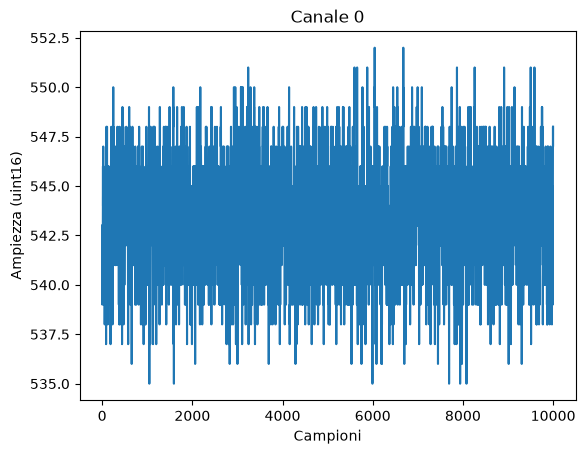

In [9]:
import matplotlib.pyplot as plt

canale = 0
plt.plot(data[:10000, canale])   # primi 10000 campioni
plt.xlabel("Campioni")
plt.ylabel("Ampiezza (uint16)")
plt.title(f"Canale {canale}")
plt.show()


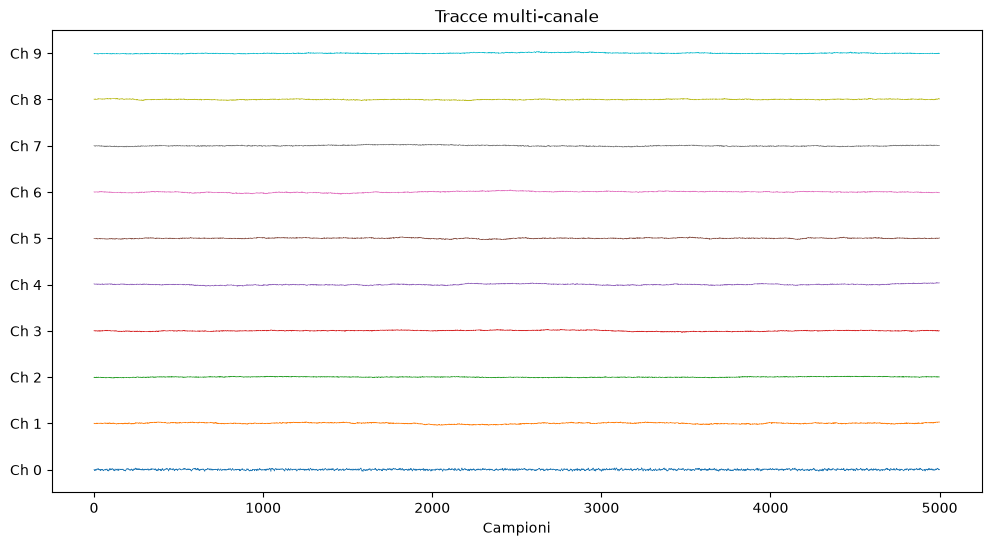

In [10]:
import numpy as np
import matplotlib.pyplot as plt

n_campioni = 5000        # finestra temporale
canali = range(10)       # primi 10 canali
offset = 200              # distanza verticale tra tracce

fig, ax = plt.subplots(figsize=(12, 6))
for i, ch in enumerate(canali):
    traccia = data[:n_campioni, ch].astype(float)
    ax.plot(traccia - traccia.mean() + i * offset, linewidth=0.5)

ax.set_yticks([i * offset for i in range(len(canali))])
ax.set_yticklabels([f"Ch {ch}" for ch in canali])
ax.set_xlabel("Campioni")
ax.set_title("Tracce multi-canale")
plt.show()


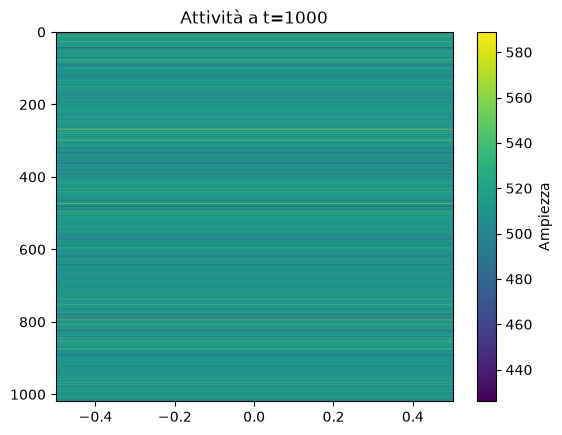

In [11]:
t = 1000
frame = data[t, :]
# se conosci le dimensioni della griglia (es. 32x32≈1024 elettrodi), fai reshape
plt.imshow(frame.reshape(-1, 1), aspect="auto", cmap="viridis")
plt.colorbar(label="Ampiezza")
plt.title(f"Attività a t={t}")
plt.show()

In [ ]:
# Run this before closing/restarting the kernel, or before trying to move/
# re-download the underlying .nwb files on disk (open HDF5 handles lock them).
for _io in ("io_raw", "io_curated"):
    if _io in globals():
        try:
            globals()[_io].close()
        except Exception:
            pass